In [830]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import uproot
import seaborn as sns
import awkward as ak
import math 

from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations, product
from scipy.optimize import minimize
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
plt.rcParams.update({'font.size': 18.0})

## Plotting equilibrium emittance $$ \epsilon_{eq} = \frac{ \beta(s) \gamma (14 MeV)^2 }{2 \beta E_{\mu}} (\frac{1}{X_0} \lvert \frac{dE_{\mu}}{dz}|^-1 )$$
## where the Bethe-Block equation as defined by section 34.2.3 in the PDG Review of Particle Physics (2024): $$ \frac{dE}{dz} = K z^{2} \frac{Z}{A} \frac{1}{\beta^2}[\frac{1}{2} ln \frac{2 m_e c^2 \beta^2 \gamma^2 W_{max}}{I^2} - \beta^2]$$  *ignoring the density effects because range of energy of interest is in the 100 MeV's

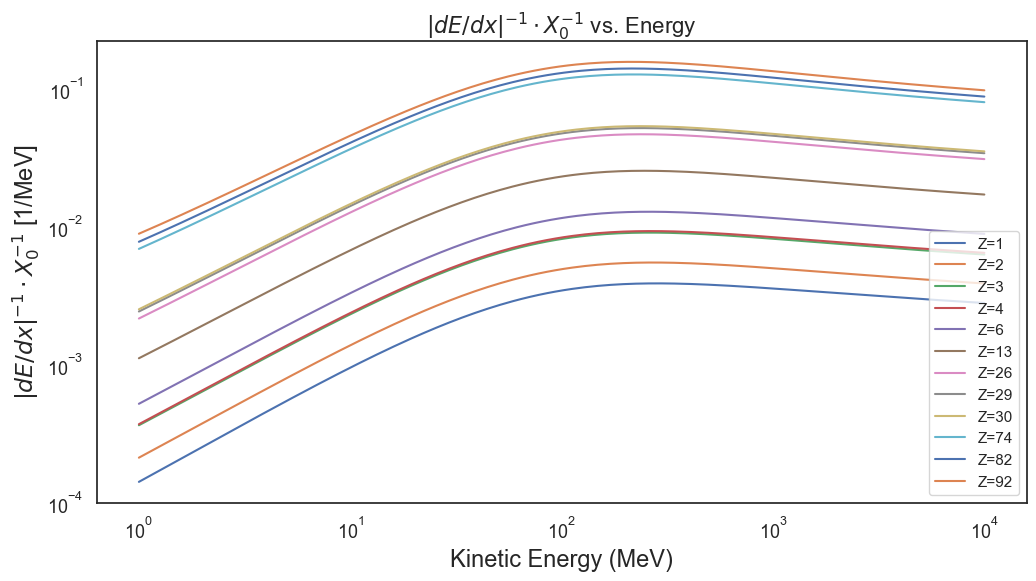

In [831]:
# Physical Constants (PDG units)
K = 0.307075  # MeV cm^2 / mol
me = 0.510998   # Electron mass (MeV/c^2)
m_mu = 105.658  # Muon mass (MeV/c^2)
m_p = 938.272  # Proton mass (MeV/c^2)

def get_material_props(Z):
    #Retrieve A, I (MeV), density (g/cm^3), and radiation length X0 (mm)."
    if Z == 1:    # Liquid Hydrogen
        A, I, rho, X0_g_cm2 = 1.008, 19.2e-6, 0.0708, 63.04
    elif Z == 2:  # Helium
        A, I, rho, X0_g_cm2 = 4.0026, 4.2e-5, 0.125, 94.3
    elif Z == 3:  # Lithium Hydride
        A, I, rho, X0_g_cm2 = 7.95, 70.0e-6, 0.78, 79.3
    elif Z == 4:  # Be
        A, I, rho, X0_g_cm2 = 9.01, 64.0e-6, 1.85, 65.19
    elif Z == 5:  # Boron
        A, I, rho, X0_g_cm2 = 10.81, 76.0e-6, 2.35, 37.8
    elif Z == 5.5:  # Approx. Polyethylene
        A, I, rho, X0_g_cm2 = 14.027, 57.0e-6, 0.9, 33.7
    elif Z == 6:  # Carbon (Graphite)
        A, I, rho, X0_g_cm2 = 12.01, 78.0e-6, 2.26, 42.70
    elif Z == 13: # Aluminum
        A, I, rho, X0_g_cm2 = 26.98, 166.0e-6, 2.70, 24.01
    else:
        # Approx.
        A = (2 * Z + 0.005 * Z**2)
        I = 10 * Z * 1e-6
        rho = 2.5 
        X0_g_cm2 = 716.4 * A / (Z * (Z + 1) * np.log(287 / np.sqrt(Z)))

    x0_mm = (X0_g_cm2 / rho) * 10  # Convert g/cm^2 to mm
    return A, I, rho, x0_mm

def bethe_bloch(T, Z):
    #Calculates -dE/dx in MeV /mm"
    A, I, rho, x0_mm = get_material_props(Z)
    gamma = (T + m_mu) / m_mu
    beta = np.sqrt(1 - 1/gamma**2)
    eta = beta * gamma
    
    # Maximum kinetic energy transfer in a single collision
    w_max = (2 * me * eta**2) / (1 + (2 * gamma * me)/m_mu + (me / m_mu)**2)
    dedx_wmass = K * (Z / A) * (1 / beta**2) * (0.5 * np.log((2 * me * eta**2 * w_max)/ (I**2)) - beta**2)
    # Convert to MeV/mm by (MeV cm^2 / g) * (g / cm^3) * (1 cm / 10 mm)
    dedx_mm = dedx_wmass * rho * 0.1
    return dedx_mm

def plot_scaled_stopping_power(Z_list, energy_range):
    plt.figure(figsize=(12, 6))
    
    for Z in Z_list:
        _, _, rho, x0_mm = get_material_props(Z)
        results = []

        for T in energy_range:
            dedx = bethe_bloch(T, Z)
            results.append((1.0 / dedx) * (1/x0_mm))
            
        plt.plot(energy_range, results, label=f'Z={Z}')
        

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Kinetic Energy (MeV)')
    plt.ylabel(r'$|dE/dx|^{-1} \cdot X_0^{-1}$ [1/MeV]')
    plt.title(r'$|dE/dx|^{-1} \cdot X_0^{-1}$ vs. Energy', fontsize=16.0)
    plt.legend(loc='lower right')
    plt.show()

energies = np.logspace(0, 4, 200)  # 1 MeV to 100 GeV
plot_scaled_stopping_power([1, 2, 3, 4, 6, 13, 26, 29, 30, 74, 82, 92], energies) 

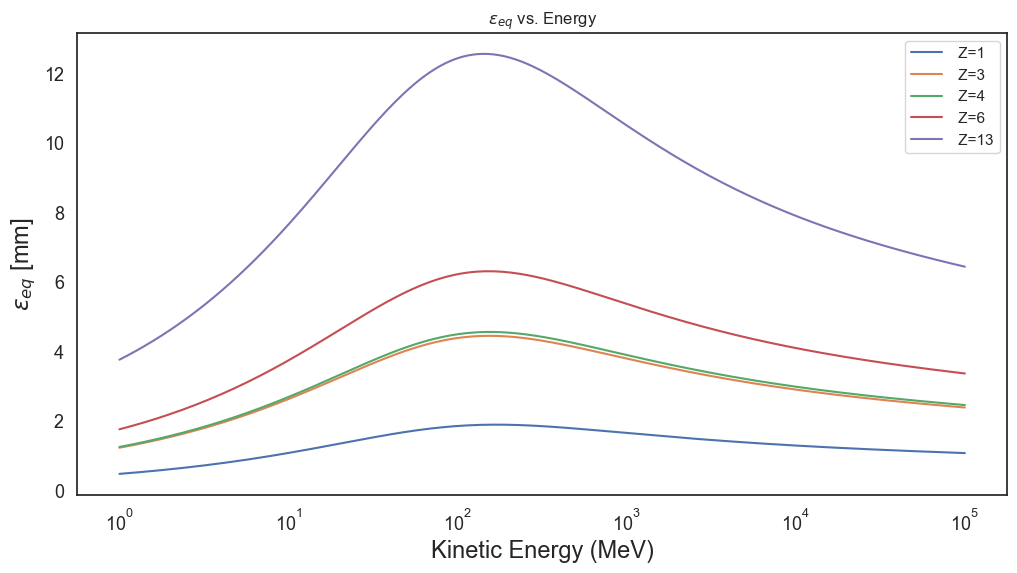

In [832]:
# Then we plot eq. emittance for all these materials 
def plot_eq_emittance(betatron_val, Z_list, energy_range):
    plt.figure(figsize=(12, 6))
    
    for Z in Z_list:
        A, I, rho, x0_mm = get_material_props(Z)
        results = []
        for T in energy_range:
            dedx = bethe_bloch(T, Z)
            scale = (1.0 / (dedx * x0_mm))
            gamma = (T + m_mu) / m_mu
            beta = np.sqrt(1 - 1/gamma**2)
            eq_factor = (betatron_val * (14.0 **2) * gamma) / (2 * beta * (T + m_mu))
            eq_emittance = eq_factor * scale
            results.append(eq_emittance)
            
        plt.plot(energy_range, results, label=f' Z={Z}')
     
    plt.xlabel('Kinetic Energy (MeV)')
    plt.ylabel(r'$\epsilon_{eq}$ [mm]')
    plt.title(r'$\epsilon_{eq}$ vs. Energy')
    plt.xscale('log')
    plt.legend(loc='upper right')
    plt.show()

# Execution
energies = np.logspace(0, 5, 200)  # 1 MeV to 100 GeV
plot_eq_emittance(500, [1, 3, 4, 6, 13], energies) # Carbon, Aluminum, Iron, Lead

## Open ROOT file from simulation with new Material Absorber and create phase space plots (modify Abs_material for each new simulation analysis)

In [833]:
Abs_material = "Lithium Hydride"
Z = 3
file = uproot.open("new_LITHIUM_HYDRIDE.root")
file.keys() #Get values for all the trackers/detectors/absorbers involved in the simulation

['VirtualDetector;1',
 'VirtualDetector/ISISVacuumTargetDet;1',
 'VirtualDetector/DiffuserDet;1',
 'VirtualDetector/TOF0;1',
 'VirtualDetector/Cherenkov1;1',
 'VirtualDetector/TOF1;1',
 'VirtualDetector/Tracker1a;1',
 'VirtualDetector/Tracker1b;1',
 'VirtualDetector/Tracker1c;1',
 'VirtualDetector/Tracker1d;1',
 'VirtualDetector/Tracker1Tracker1E;1',
 'VirtualDetector/Absa;1',
 'VirtualDetector/Absb;1',
 'VirtualDetector/Tracker2Tracker2A;1',
 'VirtualDetector/Tracker2b;1',
 'VirtualDetector/Tracker2c;1',
 'VirtualDetector/Tracker2d;1',
 'VirtualDetector/Tracker2e;1',
 'VirtualDetector/TOF2;1',
 'VirtualDetector/Cherenkov2;1',
 'VirtualDetector/Calorimeter;1',
 'NTuples;1',
 'NTuples/GoodParticle;1']

In [834]:
# Create a function that lets you know the muon number per trackers (all 1, all 2, the absorbers)
def num_muons():
    muon_data = {}  # Create a dictionary to store results
    keys = file.keys()
    
    for i in range(0, 18): 
        det_name = str(keys[i+2])
        try:
            x = file[det_name]["x"].array(library='np')
            muon_data[det_name] = len(x) 
        except Exception:
            continue # Silently skip errors 
    return muon_data  

results = num_muons()
results

{'VirtualDetector/DiffuserDet;1': 1564,
 'VirtualDetector/TOF0;1': 2716,
 'VirtualDetector/Cherenkov1;1': 2588,
 'VirtualDetector/TOF1;1': 1569,
 'VirtualDetector/Tracker1a;1': 1487,
 'VirtualDetector/Tracker1b;1': 1181,
 'VirtualDetector/Tracker1c;1': 876,
 'VirtualDetector/Tracker1d;1': 744,
 'VirtualDetector/Tracker1Tracker1E;1': 687,
 'VirtualDetector/Absa;1': 665,
 'VirtualDetector/Absb;1': 694,
 'VirtualDetector/Tracker2Tracker2A;1': 556,
 'VirtualDetector/Tracker2b;1': 548,
 'VirtualDetector/Tracker2c;1': 512,
 'VirtualDetector/Tracker2d;1': 414,
 'VirtualDetector/Tracker2e;1': 290,
 'VirtualDetector/TOF2;1': 282,
 'VirtualDetector/Cherenkov2;1': 287}

In [835]:
#examine the ttree of the good particles that made it all the way until the end of the cooling channel through every part of the model
#every branch contains the same amount of entries
ttree = file['NTuples/GoodParticle;1'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
TOF0_x               | float                    | AsDtype('>f4')
TOF0_y               | float                    | AsDtype('>f4')
TOF0_z               | float                    | AsDtype('>f4')
TOF0_Px              | float                    | AsDtype('>f4')
TOF0_Py              | float                    | AsDtype('>f4')
TOF0_Pz              | float                    | AsDtype('>f4')
TOF0_t               | float                    | AsDtype('>f4')
TOF0_PDGid           | float                    | AsDtype('>f4')
TOF0_EventID         | float                    | AsDtype('>f4')
TOF0_TrackID         | float                    | AsDtype('>f4')
TOF0_ParentID        | float                    | AsDtype('>f4')
TOF0_Weight          | float                    | AsDtype('>f4')
TOF1_x               | float                    | AsDtype(

In [836]:
#Data extractors from the detectors in the root file using uproot library
def data_extractor_det(det_name):
    # specifically to extract coords:
    branch_name_x = "{}_{}".format(det_name, "x")
    x = file['NTuples/GoodParticle;1'][branch_name_x].array()
    branch_name_y = "{}_{}".format(det_name, "y")
    y = file['NTuples/GoodParticle;1'][branch_name_y].array()
    branch_name_z = "{}_{}".format(det_name, "z")
    z = file['NTuples/GoodParticle;1'][branch_name_z].array()
    coords = np.column_stack((x, y, z,)) # given in mm 
    # specifically to extract momentums, and total mom.
    branch_name_px = "{}_{}".format(det_name, "Px")
    px = file['NTuples/GoodParticle;1'][branch_name_px].array()
    branch_name_py = "{}_{}".format(det_name, "Py")
    py = file['NTuples/GoodParticle;1'][branch_name_py].array()
    branch_name_pz = "{}_{}".format(det_name, "Pz")
    pz = file['NTuples/GoodParticle;1'][branch_name_pz].array()
    momentums = np.column_stack((px, py, pz,)) # given in MeV / c
    total_p = np.sqrt(px**2 + py**2 + pz**2)
    return coords, momentums, total_p

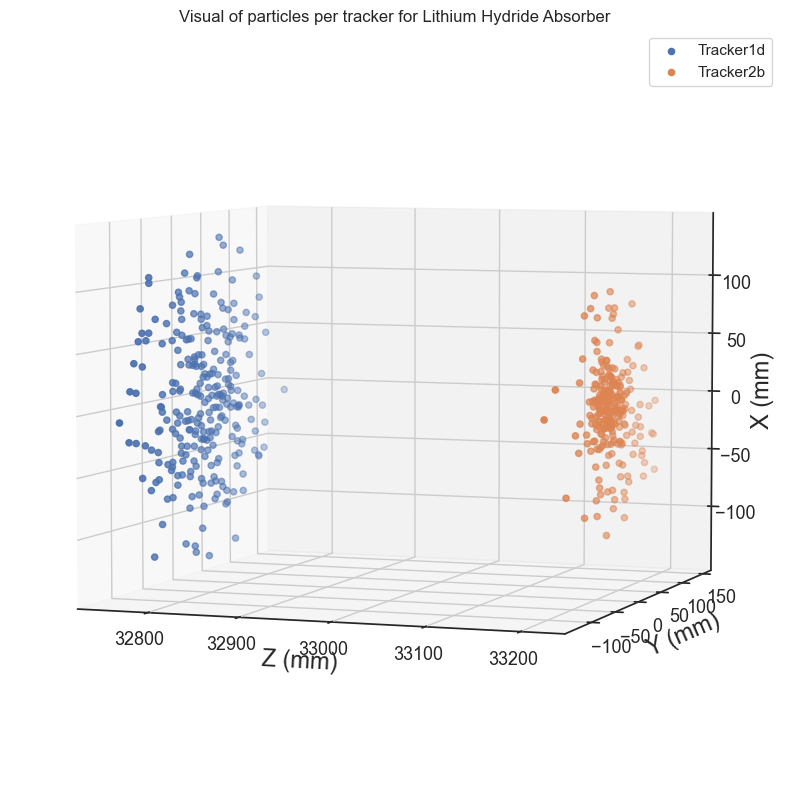

In [837]:
# Get position and momentum to calculate emittance from upstream tracker (1E) vs. downstream tracker (2A)
coords_u = data_extractor_det("Absa")[0] # in mm
mom_u = data_extractor_det("Absa")[1] # in MeV/c

coords_d = data_extractor_det("Absb")[0] # in mm
mom_d = data_extractor_det("Absb")[1] # in mm


# Visualizes spatial coordinates of good particles in the tracker (toy model) 
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(coords_u[:, 2], coords_u[:, 1], coords_u[:, 0], label="Tracker1d")
#ax.scatter(coords_d3[:, 2], coords_d3[:, 1], coords_d3[:, 0], label ="After Absorber 3 Cell")
ax.scatter(coords_d[:, 2], coords_d[:, 1], coords_d[:, 0], label="Tracker2b")

# Sets elevation to 90 (top-down) or 0 (side view)
ax.view_init(elev=5, azim=290) 
ax.set_xlabel('Z (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('X (mm)')
ax.legend()
ax.set_title('Visual of particles per tracker for {} Absorber'.format(Abs_material))
plt.show()

In [838]:
# Function that calculates the normalized transverse RMS emittance ε⟂ for any tracker spatial coords and mom. values. 
# Formula explained in report (with sources).
def emittance(x, px, y, py, m_mu):
    # Parameters are x, px, y, py (Transverse phase space coordinates (mm and MeV/c) 
    # Had to convert params from awk arrays to numpy arrays (this is necessary for the transpose calculation)
    x = ak.to_numpy(x)
    px = ak.to_numpy(px)
    y = ak.to_numpy(y)
    py = ak.to_numpy(py)
    # Create state vector u = (x, px, y, py) components into a 4xN matrix 
    u = np.column_stack((x, px, y, py))
    # Calculate the covariance matrix Σ⊥,ij = <ui*uj> - <ui><uj>
    sigma_perp = np.cov(u, rowvar=False)
    # Calculate the determinant of the covariance matrix
    det_sigma = np.linalg.det(sigma_perp)
    # Compute emittance as ε⟂ = (1/m_mu) * |Σ⟂|^(1/4)
    emittance = (1.0 / m_mu) * np.power(det_sigma, 0.25)

    u_mean = np.mean(u, axis=0)
    amp = []
    for i in u: 
        diff = i - u_mean
        # Calculate the inverse of the covariance matrix Σ⊥^-1
        sigma_inv = np.linalg.inv(sigma_perp)
        # Calculate R^2 = (ui - u_mean)^T * Σ⊥^-1 * (ui - u_mean)
        # The @ operator performs matrix multiplication in numpy (I didn't know this, it took a really long time to find)
        r_squared = diff.T @ sigma_inv @ diff
        # Find A = ε * R^2
        amplitude = emittance * r_squared
        amp.append(amplitude)
    
    return emittance, amp

# Normalized transverse RMS emittance for upstream and downstream trackers from this simulation
### AFTER EACH MATERIAL RUN I DEFINE THIS VARIABLES PER MATERIAL (THIS IS INEFFICIENT I KNOW, I JUST DIDN'T HAVE ENOUGH TIME TO CORRECT).
e_up_LiH = emittance(coords_u[:, 0], mom_u[:, 0], coords_u[:, 1], mom_u[:, 1], m_mu)[0]
e_down_LiH = emittance(coords_d[:, 0], mom_d[:, 0], coords_d[:, 1], mom_d[:, 1], m_mu)[0]
delta_e_LiH = e_down_LiH - e_up_LiH

#Estimate the transverse betatron function from the spatial coordinates of the tracker at the center of the absorber to determine value of betatron function
coords_abs = data_extractor_det("Absb")[0]
mom_abs = data_extractor_det("Absb")[1] 
e_abs_center = emittance(coords_abs[:, 0], mom_abs[:, 0], coords_abs[:, 1], mom_abs[:, 1], m_mu)[0]

betatron_LiH = ((np.mean(coords_abs[:, 0] **2) + np.mean(coords_abs[:, 1] **2)) / (e_abs_center))
print(f"The betatron function beta at the center of the absorber for this simulation is {betatron_LiH} mm")
print(f"The epsilon difference between downstream and upstream is {delta_e_LiH} mm after 1 absorber layer")
e_up_LiH

The betatron function beta at the center of the absorber for this simulation is 352.26626493537873 mm
The epsilon difference between downstream and upstream is -0.2596075731061438 mm after 1 absorber layer


6.5667721905382495

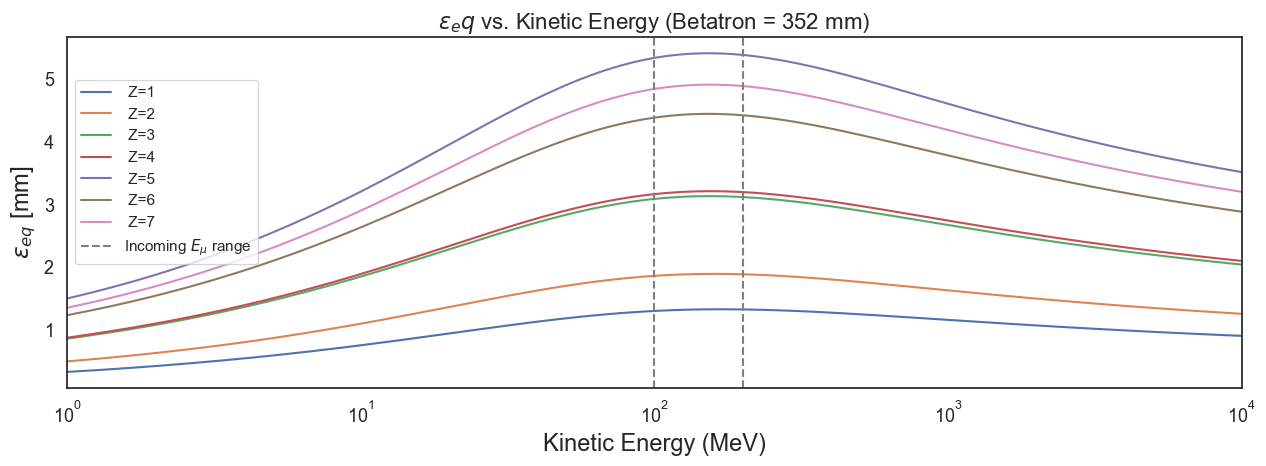

In [839]:
# Study on predicted vs. measured e_eq
total_mom_u = data_extractor_det("Tracker1d")[2] # in MeV/c
total_mom_d = data_extractor_det("Tracker2b")[2] # in MeV/c
incoming_ave_p = np.mean(total_mom_u)

# Then we plot eq. emittance for all these materials 
def plot_eq_emittance(betatron_val, Z_list, energy_range):
    plt.figure(figsize=(13, 5))
    
    for Z in Z_list:
        A, I, rho, x0_mm = get_material_props(Z)
        results = []
        for T in energy_range:
            dedx = bethe_bloch(T, Z)
            scale = (1.0 / (dedx * x0_mm))
            gamma = (T + m_mu) / m_mu
            beta = np.sqrt(1 - 1/gamma**2)
            eq_factor = (betatron_val * (14.0 **2) * gamma) / (2 * beta * (T + m_mu))
            eq_emittance = eq_factor * scale
            results.append(eq_emittance)
            
        plt.plot(energy_range, results, label=f' Z={Z}')
     
    plt.xlabel('Kinetic Energy (MeV)')
    plt.ylabel(r'$\epsilon_{eq}$ [mm]')
    plt.axvline(x = 1e2, color='gray', linestyle='--', label= r'Incoming $E_{\mu}$ range')
    plt.axvline(x = 2e2, color='gray', linestyle='--')
    plt.xlim(1, 1e4)
    plt.title(r'$\epsilon_eq$ vs. Kinetic Energy (Betatron = {} mm)'.format(math.trunc(betatron_val)), fontsize=16.0)
    plt.xscale('log')
    plt.legend(bbox_to_anchor=(0, 0.90), loc='upper left')
    plt.tight_layout() 
    plt.show()

energies = np.logspace(0, 5, 200)  # 1 MeV to 100 GeV
plot_eq_emittance(betatron_LiH, [1, 2, 3, 4, 5, 6, 7], energies) # Z allowed for this betatron value

In [840]:
# VS CALCULATED FROM SIMULATION AND EXPRESSION DERIVED IN PAPER
KE = np.sqrt(incoming_ave_p**2 + m_mu**2) - m_mu # in MeV
print(KE) 

def calculate_deltae_abs_simulation(betatron_val, e_up, KE, Z):
    #calculate eq_emittance for atomic number Z 
    A, I, rho, x0_mm = get_material_props(Z)
    dedx = bethe_bloch(KE, Z)
    scale = (1.0 / (dedx * x0_mm))
    gamma = (KE + m_mu)/ m_mu
    beta = np.sqrt(1 - 1/gamma**2)
    eq_factor = (betatron_val * (14.0**2) * gamma) / (2 * beta * (KE + m_mu))
    eq_emittance = eq_factor * scale 
    #using expression derived in paper:
    abs_length = 65 #mm to cancel out units with bethe_bloch eq (MeV/mm)
    delta_e = (eq_emittance - e_up)*(1.0-(np.exp((-dedx * abs_length)/((beta**2) * (KE + m_mu)))))
    return delta_e, eq_emittance

##### CHANGE BASED ON ABSORBER (Z)
exp_eeq_LiH = calculate_deltae_abs_simulation(betatron_LiH, e_up_LiH, KE, Z)
exp_eeq_LiH

139.0135591985018


(-0.12520836110428016, 3.1327469584515244)

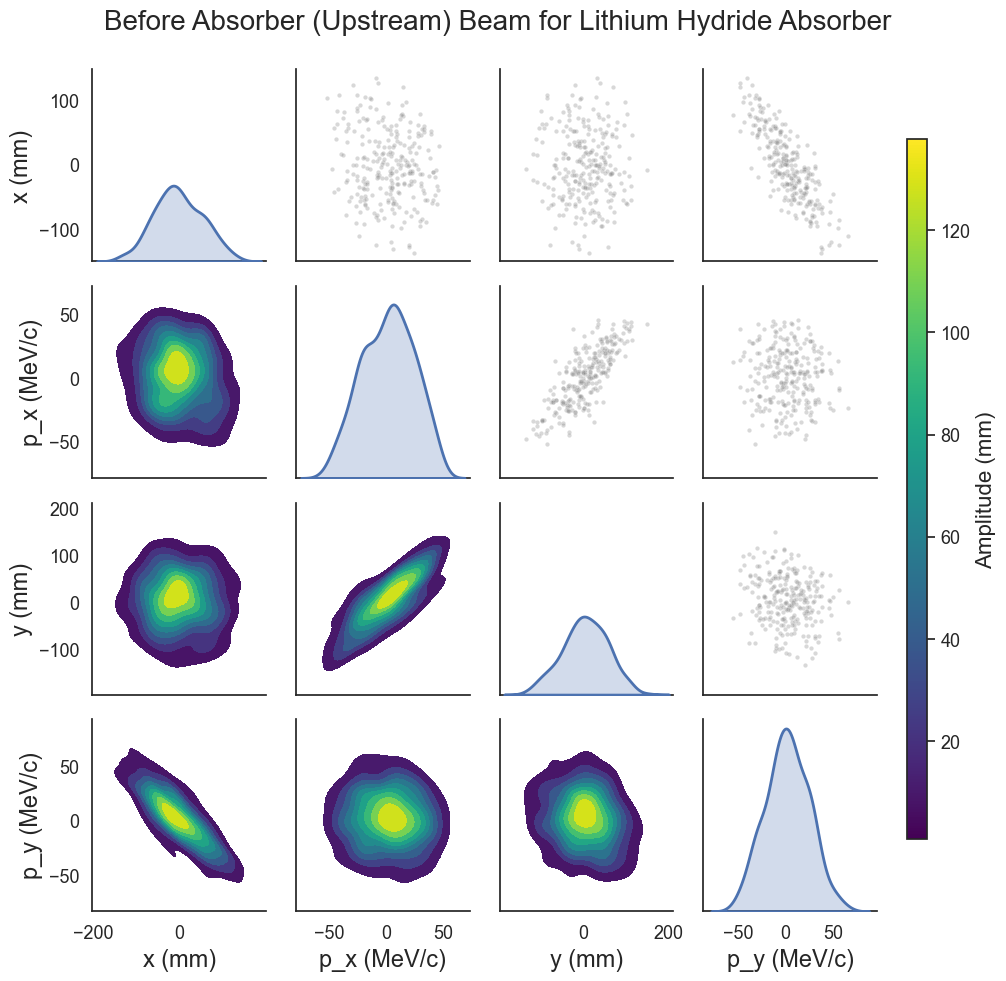

In [841]:
# Do a downstream emittance plot
particle_amp_up = emittance(coords_u[:, 0], mom_u[:, 0], coords_u[:, 1], mom_u[:, 1], m_mu)[1]
df = pd.DataFrame({'x (mm)': coords_u[:, 0], 'y (mm)': coords_u[:, 1], 'p_x (MeV/c)': mom_u[:, 0], 'p_y (MeV/c)': mom_u[:, 1], 'Amplitude (mm)': particle_amp_up})

sns.set_theme(style="white", rc={
    "axes.labelsize": 17,      # Size of 'x', 'px', etc. labels
    "xtick.labelsize": 13,     # Size of x-axis tick numbers
    "ytick.labelsize": 13      # Size of y-axis tick numbers
})

plot_vars = ['x (mm)', 'p_x (MeV/c)', 'y (mm)', 'p_y (MeV/c)']
g = sns.PairGrid(df, vars=plot_vars)

g.map_upper(sns.scatterplot, s=10, alpha=0.3, color="gray")
g.map_lower(sns.kdeplot, fill=True, cmap="viridis")
g.map_diag(sns.kdeplot, lw=2, fill=True)

# Create the colorbar based on range of amplitudes
norm = mcolors.Normalize(vmin=df['Amplitude (mm)'].min(), vmax=df['Amplitude (mm)'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# placement of the colorbar and figure
g.figure.subplots_adjust(right=0.88, top=0.92)
cbar_ax = g.figure.add_axes([0.91, 0.15, 0.02, 0.7]) 
cb = g.figure.colorbar(sm, cax=cbar_ax)
cb.set_label('Amplitude (mm)', fontsize=16)

g.figure.suptitle('Before Absorber (Upstream) Beam for {} Absorber'.format(Abs_material), fontsize=20)
plt.savefig('upstream_{}.png'.format(Abs_material))
plt.show()

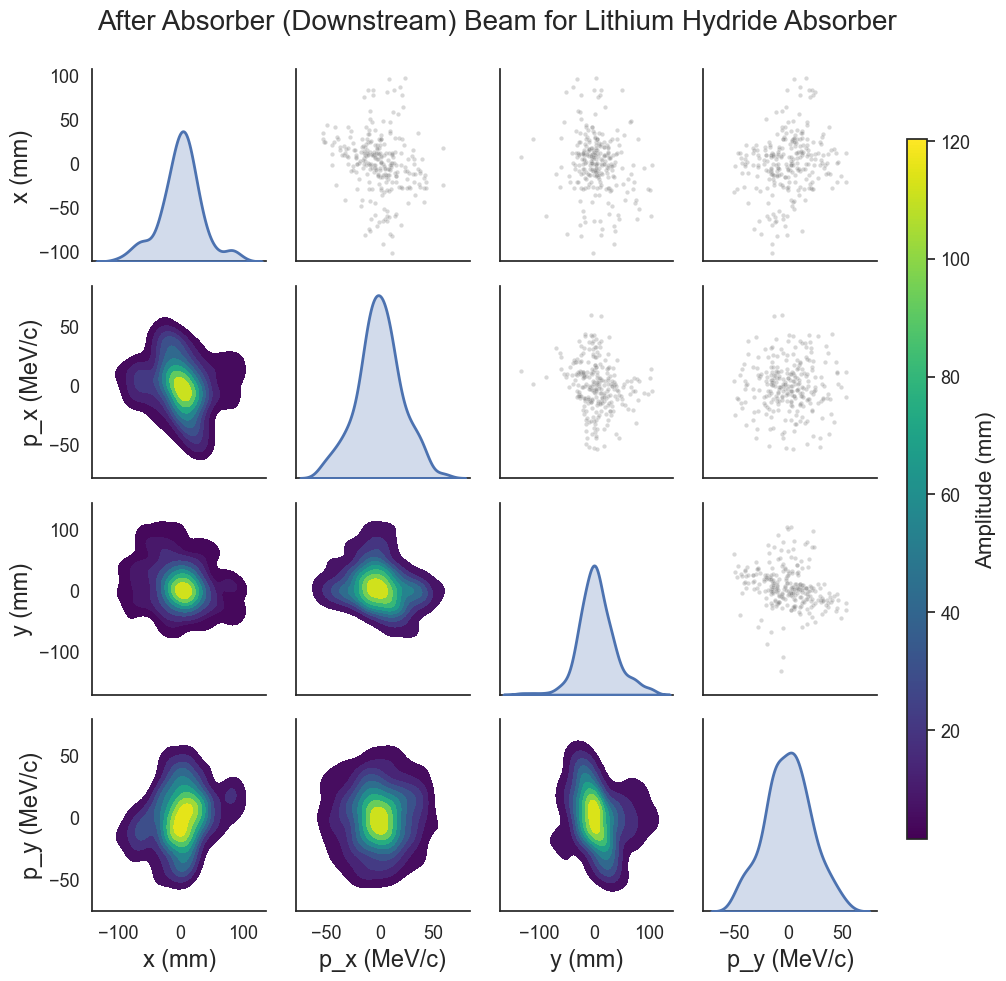

In [842]:
# Do a downstream emittance plot
particle_amp_down = emittance(coords_d[:, 0], mom_d[:, 0], coords_d[:, 1], mom_d[:, 1], m_mu)[1]
df = pd.DataFrame({'x (mm)': coords_d[:, 0], 'y (mm)': coords_d[:, 1], 'p_x (MeV/c)': mom_d[:, 0], 'p_y (MeV/c)': mom_d[:, 1], 'Amplitude (mm)': particle_amp_down})

sns.set_theme(style="white", rc={
    "axes.labelsize": 17,      # Size of 'x', 'px', etc. labels
    "xtick.labelsize": 13,     # Size of x-axis tick numbers
    "ytick.labelsize": 13      # Size of y-axis tick numbers
})

plot_vars = ['x (mm)', 'p_x (MeV/c)', 'y (mm)', 'p_y (MeV/c)']
g = sns.PairGrid(df, vars=plot_vars)

g.map_upper(sns.scatterplot, s=10, alpha=0.3, color="gray")
g.map_lower(sns.kdeplot, fill=True, cmap="viridis")
g.map_diag(sns.kdeplot, lw=2, fill=True)

# Create the colorbar based on range of amplitudes
norm = mcolors.Normalize(vmin=df['Amplitude (mm)'].min(), vmax=df['Amplitude (mm)'].max())
sm = cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# placement of the colorbar and figure
g.figure.subplots_adjust(right=0.88, top=0.92)
cbar_ax = g.figure.add_axes([0.91, 0.15, 0.02, 0.7]) 
cb = g.figure.colorbar(sm, cax=cbar_ax)
cb.set_label('Amplitude (mm)', fontsize=16)

g.figure.suptitle('After Absorber (Downstream) Beam for {} Absorber'.format(Abs_material), fontsize=20)
plt.savefig('downstream_{}.png'.format(Abs_material))
plt.show()

## Figure out whether or not there was cooling and why or why not? 

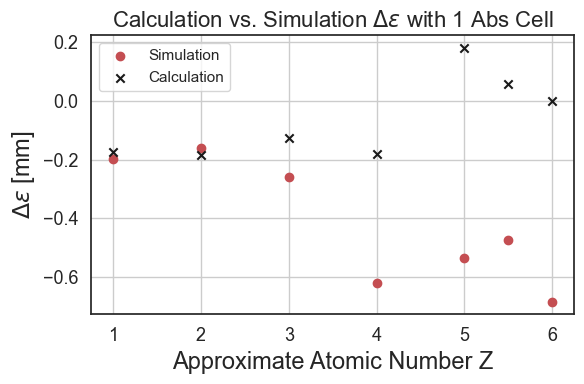

In [858]:
# Plot the simulation e_eq vs. calculated value e_eq
Z = np.array([1,2,3,4,6,5.5,5])                
calc_eeq = np.array([exp_eeq_LH2[0], exp_eeq_LHe[0], exp_eeq_LiH[0], exp_eeq_Be[0], exp_eeq_C[0], exp_eeq_poly[0], exp_eeq_B[0]])  
sim_eeq = np.array([delta_e_LH2, delta_e_LHe, delta_e_LiH, delta_e_Be, delta_e_C, delta_e_poly, delta_e_B])

fig = plt.figure(figsize=(6, 4))
plt.scatter(Z, sim_eeq, c='r', marker='o', label='Simulation')
plt.scatter(Z, calc_eeq, c='k', marker='x', label='Calculation') 

plt.xlabel(r'Approximate Atomic Number Z')
plt.ylabel(r'$\Delta \epsilon$ [mm]')
plt.title(r'Calculation vs. Simulation $ \Delta \epsilon$ with 1 Abs Cell', fontsize=16.0)
plt.legend() # Uncommented to see labels
plt.grid(True)
plt.tight_layout()
plt.savefig('deltaE_Absab_.png')
plt.show()

<Figure size 700x300 with 0 Axes>

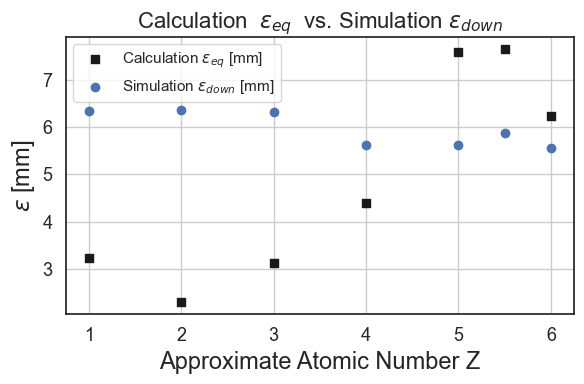

In [857]:
fig = plt.figure(figsize=(7, 3))
calc_eeq_emit = np.array([exp_eeq_LH2[1], exp_eeq_LHe[1], exp_eeq_LiH[1], exp_eeq_Be[1], exp_eeq_C[1], exp_eeq_poly[1], exp_eeq_B[1]])  
e_down = np.array([e_down_LH2, e_down_LHe, e_down_LiH, e_down_Be, e_down_C, e_down_poly, e_down_B])

fig = plt.figure(figsize=(6, 4))
plt.scatter(Z, calc_eeq_emit, c='k', marker='s', label=r'Calculation $\epsilon_{eq}$ [mm]')
plt.scatter(Z, e_down, c='b', marker='o', label=r'Simulation $\epsilon_{down}$ [mm]')
plt.xlabel(r'Approximate Atomic Number Z')
plt.ylabel(r'$\epsilon$ [mm]')
plt.title(r'Calculation  $\epsilon_{eq}$  vs. Simulation $\epsilon_{down}$', fontsize=16.0)
plt.legend(loc='upper left') # Uncommented to see labels
plt.grid(True)
plt.tight_layout()
plt.savefig('cooling?.png')
plt.show()